# CNC Predictive Maintenance — Exploratory Data Analysis

## Project Overview

This project explores machine sensor and operational data to understand

the factors associated with machine failure.

The goal is to investigate the data first, identify patterns and data-quality

issues, and develop research questions that can later be investigated using

statistical and machine-learning methods.

## Main Focus

- Understand the structure of the dataset

- Explore the variables and their distributions

- Check data quality

- Investigate relationships between machine conditions and failure

- Identify patterns related to tool wear and machine failure

- Prepare the data for later predictive modelling

## Dataset

The dataset contains information about machine operating conditions,

including variables such as:

- air temperature

- process temperature

- rotational speed

- torque

- tool wear

- machine failure

## Approach

1. Load and inspect the data

2. Understand the variables

3. Check data quality

4. Explore distributions

5. Investigate relationships between variables

6. Formulate research questions

7. Prepare for predictive modelling

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport

%matplotlib inline

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/7r/z88gd3sd0rv_x899l45rkmm40000gn/T/ipykernel_55120/525096276.py:4: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [2]:
import os
print(os.getcwd())

/Users/c.m./Documents/portfolio_projects/Data_Analytics/CNC_Manufacturing_Analytics/notebooks


## Load Dataset

In [3]:
df = pd.read_csv("../data/ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Initial Data Exploration

In [4]:
df.shape
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

## Data Quality Assessment

In [5]:
profile = ProfileReport(df, 
                        title = "CNC Predictive Maintenance Data Quality Report", 
                        explorative = True
                       )

In [6]:
profile.to_file("../reports/cnc_data_quality_report.html")

Export report to file: 100%|███████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 207.89it/s]


## Overview Observations


* The dataset contains 10,000 machine records and 14 variables.
* There are no missing values.
* The dataset contains both machine operating conditions and machine failure indicators.
* Machine failure is relatively rare compared with normal operation.
* The main continuous variables are:
    * Air temperature
    * Process temperature
    * Rotational speed
    * Torque
    * Tool wear
* Failure types are represented by TWF, HDF, PWF, OSF, and RNF.
* These observations will guide the next stage of the EDA: exploring the distributions of the variables.

## Explore Distributions

In [7]:
df[['Air temperature [K]',
    'Process temperature [K]', 
    'Rotational speed [rpm]', 
    'Torque [Nm]', 
    'Tool wear [min]']].describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000
std,2.000259,1.483734,179.284096,9.968934,63.654147
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


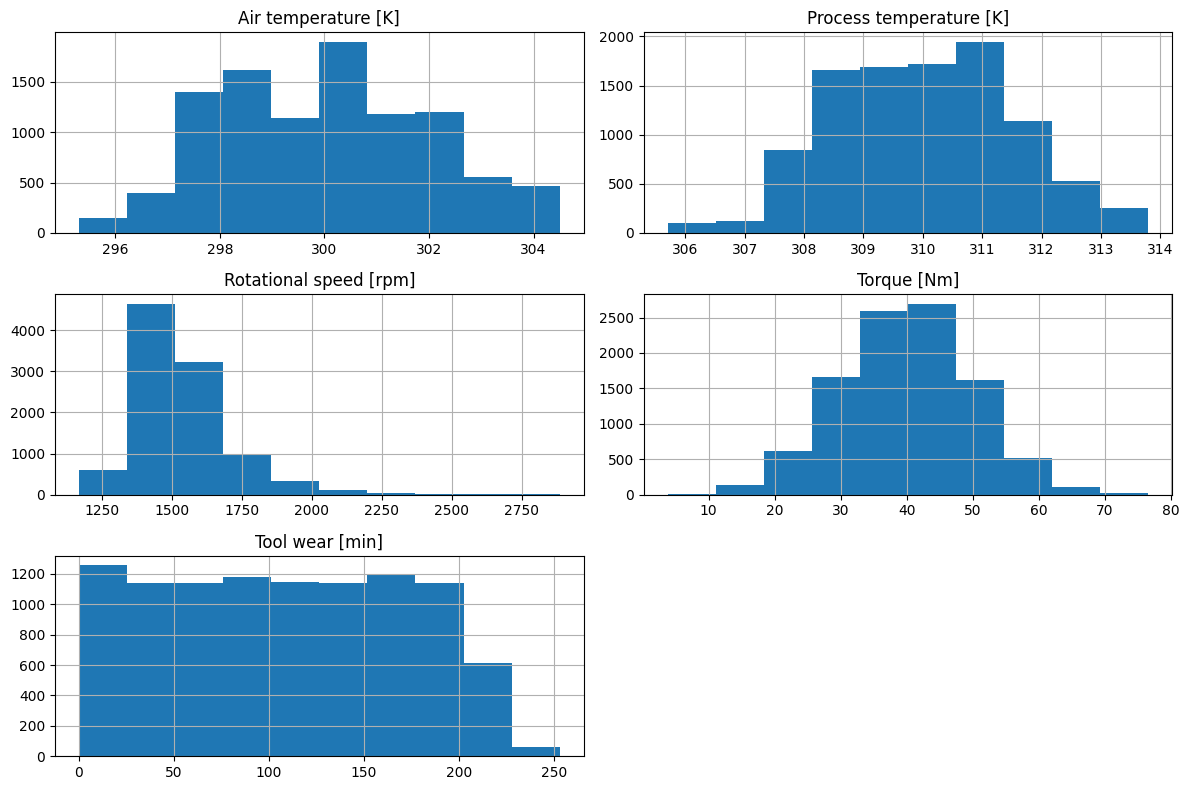

In [8]:
df[['Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]']].hist(figsize=(12, 8))

plt.tight_layout()
plt.show()

### Distribution Observations

- Air temperature is concentrated around the middle of its range, with relatively few observations at the extremes.

- Process temperature is also concentrated within a relatively narrow range.

- Rotational speed is concentrated around the middle range, with fewer observations at higher speeds.

- Tool wear is spread across a broad range, from low to high tool-wear values.

### Machine Failure Distribution

In [9]:
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

### Machine Failure Distribution — Observations

The dataset contains **9,661 observations without machine failure (96.61%)** and **339 observations with machine failure (3.39%)**.

Machine failures therefore represent a relatively small proportion of the observations.

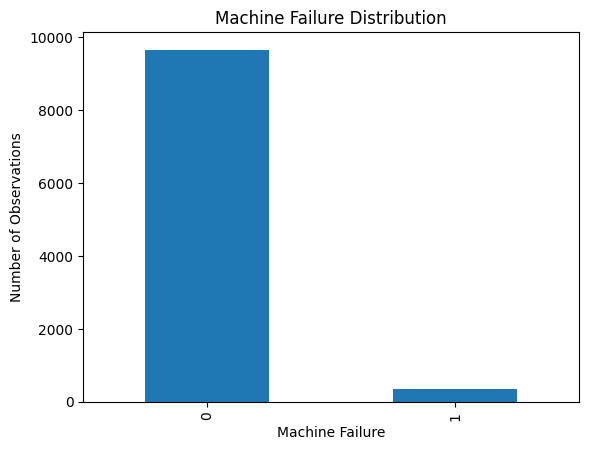

In [10]:
df['Machine failure'].value_counts().plot(kind='bar')

plt.title('Machine Failure Distribution')

plt.xlabel('Machine Failure')

plt.ylabel('Number of Observations')

plt.show()

### Machine Failure Distribution — Interpretation

The chart shows that normal machine operation is much more common than machine failure.

There are 9,661 observations without machine failure compared with 339 observations with machine failure. This indicates that machine failure is relatively rare in the dataset.

Because failures are relatively rare, the next analysis should compare machine operating conditions between failed and non-failed observations.

## Compare Operating Conditions by Machine Failure

### Torque by Machine Failure

In [11]:
df.groupby('Machine failure')['Torque [Nm]'].describe()

,count,mean,std,min,25%,50%,75%,max
Machine failure,,,,,,,,
0,9661.0,39.629655,9.472080,12.6,33.10,39.9,46.3,70.0
1,339.0,50.168142,16.374498,3.8,45.95,53.7,61.2,76.6


### Observation

Failed machines show higher torque values than non-failed machines. The mean torque is 50.17 Nm for failed observations compared with 39.63 Nm for non-failed observations. The median is also higher for failed machines (53.7 Nm compared with 39.9 Nm).

This suggests that higher torque may be associated with machine failure and should be investigated further.

### Rotational Speed by Machine Failure

In [12]:
df.groupby('Machine failure')['Rotational speed [rpm]'].describe()

,count,mean,std,min,25%,50%,75%,max
Machine failure,,,,,,,,
0,9661.0,1540.260014,167.394734,1168.0,1429.0,1507.0,1615.0,2695.0
1,339.0,1496.486726,384.943547,1181.0,1326.5,1365.0,1421.5,2886.0


### Observation

Failed machines show lower typical rotational speeds than non-failed machines. The median rotational speed is 1,365 rpm for failed observations compared with 1,507 rpm for non-failed observations.

Failed machines also show much greater variation in rotational speed, with a standard deviation of 384.94 rpm compared with 167.39 rpm for non-failed machines.

This suggests that lower and more variable rotational speed may be associated with machine failure and should be investigated further.

### Tool Wear by Machine Failure

In [13]:
df.groupby('Machine failure')['Tool wear [min]'].describe()

,count,mean,std,min,25%,50%,75%,max
Machine failure,,,,,,,,
0,9661.0,106.693717,62.945790,0.0,52.0,107.0,160.0,246.0
1,339.0,143.781711,72.759876,0.0,84.5,165.0,207.5,253.0


### Observation

Failed machines show higher tool wear than non-failed machines. The mean tool wear is 143.78 minutes for failed observations compared with 106.69 minutes for non-failed observations. The median is also higher for failed machines, at 165 minutes compared with 107 minutes for non-failed machines.

This suggests that higher tool wear may be associated with machine failure and should be investigated further.